<h3>Artificial Neural Network (ANN) Classification</h3>
<h3>Author: Vicky Law</h3>
<h3>Date: Apr 17, 2026</h3>

# Introduction:
This notebook implements a full data analytics pipeline using an Artificial Neural Network (ANN) model on the given dataset. The objective is to predict the label based on user activity and security-related features such as login attempts, failed logins, session duration, transferred data, file access behavior, IP reputation score, and unusual port access.
The pipeline includes: 
1. load dataset
2. check info / null / duplicates
3. clean data
4. separate X and y
5. check class distribution 
6. train-test split
7. scaling
8. ANN model
9. training
10. prediction
11. evaluation

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset

In [2]:
df = pd.read_csv("th5.csv")
df.head()

,ID,Login_Attempts,Failed_Logins,Session_Duration,Data_Transferred,Accessed_Sensitive_Files,IP_Reputation_Score,Unusual_Port_Access,Label
0,1,3,0,15,50,0,80,0,0
1,2,10,7,5,10,1,20,1,1
2,3,2,0,30,70,0,90,0,0
3,4,15,10,3,5,1,10,1,1
4,5,5,1,20,60,0,75,0,0


# Step 2: Understand the dataset

In [3]:
# Display the number of rows and columns in the dataset
df.shape

(10, 9)

In [4]:
# Display general information about the dataset such as column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   ID                        10 non-null     int64
 1   Login_Attempts            10 non-null     int64
 2   Failed_Logins             10 non-null     int64
 3   Session_Duration          10 non-null     int64
 4   Data_Transferred          10 non-null     int64
 5   Accessed_Sensitive_Files  10 non-null     int64
 6   IP_Reputation_Score       10 non-null     int64
 7   Unusual_Port_Access       10 non-null     int64
 8   Label                     10 non-null     int64
dtypes: int64(9)
memory usage: 852.0 bytes


In [5]:
# Display summary statistics for all numerical columns
df.describe()

,ID,Login_Attempts,Failed_Logins,Session_Duration,Data_Transferred,Accessed_Sensitive_Files,IP_Reputation_Score,Unusual_Port_Access,Label
count,10.00000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,9.200000,5.400000,12.40000,31.200000,0.500000,48.300000,0.500000,0.500000
std,3.02765,6.746192,5.699903,10.51137,26.976533,0.527046,35.715076,0.527046,0.527046
min,1.00000,2.000000,0.000000,2.00000,3.000000,0.000000,5.000000,0.000000,0.000000
25%,3.25000,3.250000,0.250000,3.25000,6.500000,0.000000,16.250000,0.000000,0.000000
50%,5.50000,7.500000,4.000000,10.00000,27.500000,0.500000,50.000000,0.500000,0.500000
75%,7.75000,14.250000,9.500000,19.50000,53.750000,1.000000,79.500000,1.000000,1.000000
max,10.00000,20.000000,15.000000,30.00000,70.000000,1.000000,90.000000,1.000000,1.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()

ID                          0
Login_Attempts              0
Failed_Logins               0
Session_Duration            0
Data_Transferred            0
Accessed_Sensitive_Files    0
IP_Reputation_Score         0
Unusual_Port_Access         0
Label                       0
dtype: int64

In [7]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [8]:
# Check the column names
print(df.columns)

Index(['ID', 'Login_Attempts', 'Failed_Logins', 'Session_Duration',
       'Data_Transferred', 'Accessed_Sensitive_Files', 'IP_Reputation_Score',
       'Unusual_Port_Access', 'Label'],
      dtype='object')


# Step 3: Clean the data
The dataset contains an ID column, which is only a unique identifier and not useful for prediction, so it was removed from the feature set. The missing value check showed no null values, and no duplicate records were found. Therefore, only minor preprocessing was required before model training.

# Step 4: Separate features and target

In [9]:
# Separate the input features (X) from the target variable (y)
X = df.drop(["ID", "Label"], axis=1)
y = df["Label"]

# Display the distribution of the target classes
print("\nClass distribution:")
print(y.value_counts())


Class distribution:
Label
0    5
1    5
Name: count, dtype: int64


# Step 5: Split into training and testing sets

In [10]:
# Split the dataset into training and testing sets
# 80% of the data is used for training and 20% is used for testing
# stratify=y keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 8
Testing size: 2


# Step 6: Scale the features

In [11]:
# Create a StandardScaler object to standardize the feature values
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the testing data
X_test_scaled = scaler.transform(X_test)

print("\nTraining feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)


Training feature shape: (8, 7)
Testing feature shape: (2, 7)


# Step 7: Build the ANN model
The hidden layer setting (16, 8) means the ANN uses two hidden layers, with 16 neurons in the first layer and 8 neurons in the second layer. This structure was selected as a simple and reasonable starting architecture to help the model learn nonlinear patterns in the data without making the network too complex for such a small dataset.

In [12]:
# Build the ANN model using MLPClassifier
# hidden_layer_sizes=(16, 8) means two hidden layers with 16 and 8 neurons
# activation='relu' defines the activation function
# solver='adam' is the optimization algorithm used for training
# max_iter=1000 means the model will train for up to 1000 iterations
# random_state=42 ensures reproducible results
ann_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Step 8: Train the ANN model

In [13]:
# Train the ANN model using the scaled training data
ann_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


# Step 9: Make predictions

In [14]:
# Use the trained model to make predictions on the test data
y_pred = ann_model.predict(X_test_scaled)

# Step 10: Evaluate the model

In [15]:
# Calculate the overall accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 1.0


The model achieved 100% accuracy on the test set. However, since the dataset is very small and the test set contains only two records, this result should be interpreted cautiously.

In [16]:
# Display the classification report including precision, recall, and F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [17]:
# Generate the confusion matrix to compare actual and predicted labels
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 1]]


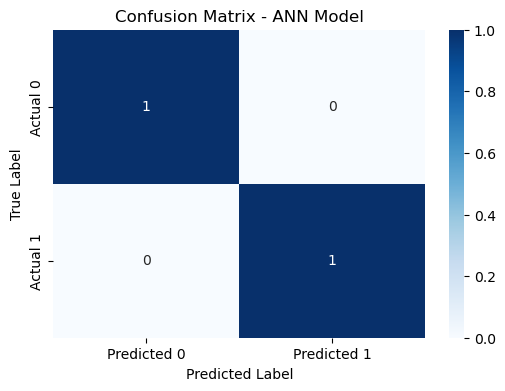

In [18]:
# Plot the confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - ANN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Step 11: Show model loss curve

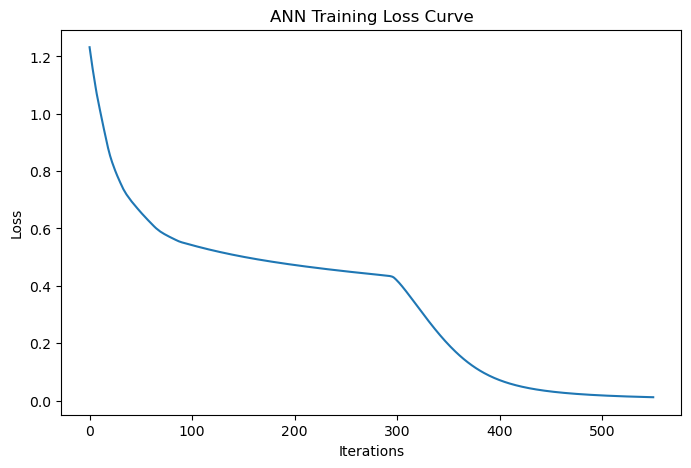

In [19]:
# Plot the training loss curve to show how the ANN model learned over iterations
plt.figure(figsize=(8,5))
plt.plot(ann_model.loss_curve_)
plt.title("ANN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

### Observations:
- The ANN model was trained using scaled numerical features from the dataset.
- Feature scaling was necessary because neural networks are sensitive to differences in feature magnitude.
- The model was evaluated using accuracy, classification report, and confusion matrix.
- The loss curve shows how the model learned over training iterations.
- Since the dataset is very small, the model results should be interpreted mainly as a demonstration of the ANN pipeline rather than as a highly generalizable predictive system.

### Difference Between ANN and Previous ML Models

The ANN model is different from previous machine learning models such as Logistic Regression, Decision Tree, or Random Forest because it learns through interconnected layers of neurons rather than using a direct mathematical relationship or tree-based decision rules. ANN is especially useful for capturing more complex and nonlinear patterns in the data, while many traditional ML models are simpler and often easier to interpret. In this model, the network learns the best values for weights and biases during training across hidden layers to improve prediction performance. However, compared with previous ML models, ANN usually requires feature scaling, more training time, and more parameter tuning such as selecting the number of hidden layers, neurons, and iterations.

## Conclusion:
This notebook implemented a complete ANN-based classification pipeline, including data loading, preprocessing, train-test splitting, feature scaling, model training, prediction, and evaluation. The ANN model was able to learn patterns from the numerical security-related features and produce classification results on the test set. Although the dataset is very small, the notebook successfully demonstrates the full workflow of using an Artificial Neural Network for classification.